In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = sns.load_dataset('diamonds')

In [3]:
df.head(5)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [5]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [6]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [7]:
df['volume'] = df['x'] * df['y'] * df['z']
df["volume"]

0         38.202030
1         34.505856
2         38.076885
3         46.724580
4         51.917250
            ...    
53935    115.920000
53936    118.110175
53937    114.449728
53938    140.766120
53939    124.568444
Name: volume, Length: 53940, dtype: float64

In [8]:
df_numeric = df.select_dtypes(include=["int64","float64"])
df_numeric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   carat   53940 non-null  float64
 1   depth   53940 non-null  float64
 2   table   53940 non-null  float64
 3   price   53940 non-null  int64  
 4   x       53940 non-null  float64
 5   y       53940 non-null  float64
 6   z       53940 non-null  float64
 7   volume  53940 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 3.3 MB


In [9]:
df_numeric.head()

,carat,depth,table,price,x,y,z,volume
0,0.23,61.5,55.0,326,3.95,3.98,2.43,38.202030
1,0.21,59.8,61.0,326,3.89,3.84,2.31,34.505856
2,0.23,56.9,65.0,327,4.05,4.07,2.31,38.076885
3,0.29,62.4,58.0,334,4.20,4.23,2.63,46.724580
4,0.31,63.3,58.0,335,4.34,4.35,2.75,51.917250


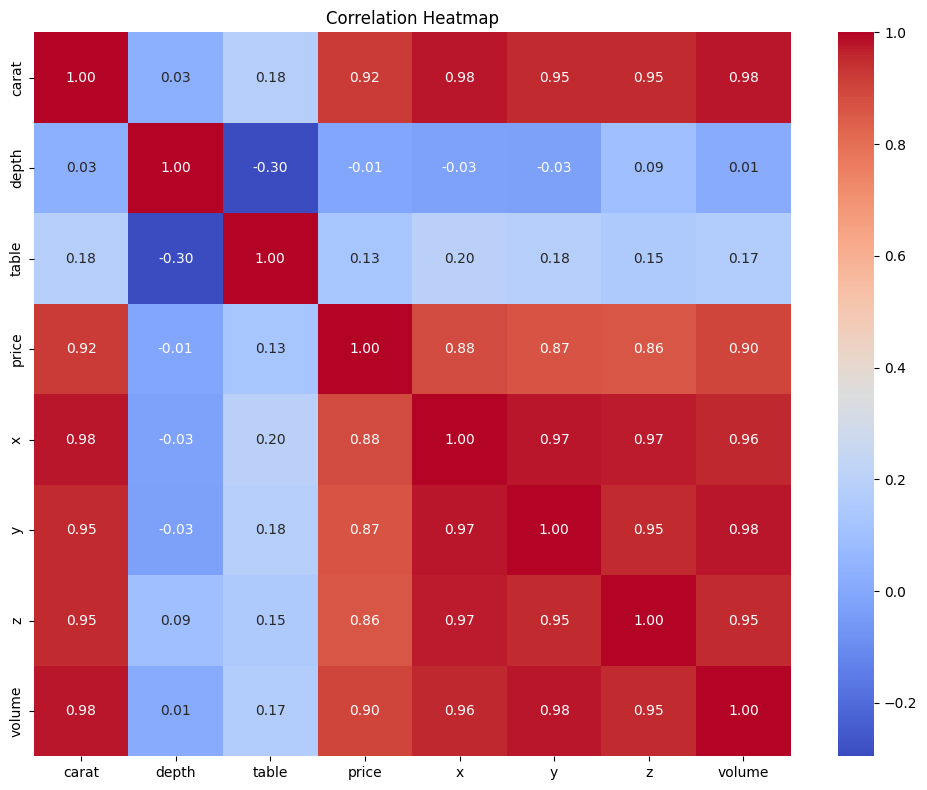

In [10]:
plt.figure(figsize=(10,8))
correlation_matrix = df_numeric.corr()
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [12]:
df_plan = df.drop(columns=["x","y","z","volume"])
df_plan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
dtypes: category(3), float64(3), int64(1)
memory usage: 1.8 MB


In [20]:
df_final = pd.get_dummies(df_plan,columns=["cut","color","clarity"])
df_final.head()

,carat,depth,table,price,cut_Ideal,cut_Premium,cut_Very Good,cut_Good,cut_Fair,color_D,...,color_I,color_J,clarity_IF,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
0,0.23,61.5,55.0,326,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,0.21,59.8,61.0,326,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,0.23,56.9,65.0,327,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
3,0.29,62.4,58.0,334,False,True,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
4,0.31,63.3,58.0,335,False,False,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False


In [21]:
df_final.shape

(53940, 24)

In [17]:
from sklearn.preprocessing import StandardScaler

In [22]:
#SEPERATING DATA
X= df_final.drop("price",axis=1) #X MATRIX (FEATURES) M*N TYPE MATRIX
y = df_final["price"] #Y MATRIX (TARGET)  # M*1 VECTOR

## Z-SCORE NORMALIZATION (FIT DATA 0-1)

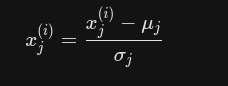

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [29]:
# LINEAR REGRESSION
from sklearn.linear_model import LinearRegression
#: fw,b​(x(i))=w⋅x(i)+b (w,b = 0,0)
model = LinearRegression()
#Gradient Descent,Cost function,Alpha optimization
model.fit(X_scaled , y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
# 1. Modelin bulduğu w (ağırlıklar) ve b (sapma) değerlerini görelim
print(" (w):\n", model.coef_)
print("\n(b):", model.intercept_)

# 2. Hangi özelliğin fiyata ne kadar etkisi var?
features_list = X.columns
weights = model.coef_

for feature, weight in zip(features_list, weights):
    print(f"{feature}: {weight:.2f}")

 (w):
 [ 4.21638290e+03 -3.01185923e+01 -5.54209760e+01  5.33946108e+01
  1.63448245e+01  4.11555427e+00 -4.43196747e+01 -1.30783601e+02
  2.09826250e+02  1.62812591e+02  1.25488497e+02  5.13374096e+01
 -1.24446982e+02 -2.42094634e+02 -3.75293001e+02  2.58220796e+02
  2.76244237e+02  2.90166106e+02  2.01765937e+02  1.03746002e+02
 -1.69154364e+02 -5.05236745e+02 -4.61246179e+02]

(b): 3932.799721913236
carat: 4216.38
depth: -30.12
table: -55.42
cut_Ideal: 53.39
cut_Premium: 16.34
cut_Very Good: 4.12
cut_Good: -44.32
cut_Fair: -130.78
color_D: 209.83
color_E: 162.81
color_F: 125.49
color_G: 51.34
color_H: -124.45
color_I: -242.09
color_J: -375.29
clarity_IF: 258.22
clarity_VVS1: 276.24
clarity_VVS2: 290.17
clarity_VS1: 201.77
clarity_VS2: 103.75
clarity_SI1: -169.15
clarity_SI2: -505.24
clarity_I1: -461.25


In [34]:
from sklearn.model_selection import train_test_split

# 1. VERİYİ BÖLME (X_test burada doğuyor)
# Elimizdeki 53 bin elmasın %80'ini eğitime (train), %20'sini sınava (test) ayırıyoruz.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. HİZAYA SOKMA (Scaled işlemi)
# Eğitimi hizala:
X_train_scaled = scaler.fit_transform(X_train) 
# Sınavı hizala (Senin sorduğun ve hata veren X_test_scaled işte tam burada oluşuyor):
X_test_scaled = scaler.transform(X_test)       

# 3. MODELİ EĞİTME
# Modeli SADECE %80'lik eğitim verisiyle çalıştırıyoruz.
model.fit(X_train_scaled, y_train)

# 4. TAHMİN (PREDICTION) AŞAMASI
# SYNTAX BUDUR: model.predict(görülmemiş_veri)
# Modele diyoruz ki: "Al bu %20'lik hiç görmediğin sınav kağıdını, bana fiyatları tahmin et."
tahminler = model.predict(X_test_scaled)

# Sonuçları gözümüzle görelim:
print("İlk 3 elmasın GERÇEK fiyatı:", y_test.values[:3])
print("Modelin TAHMİN ETTİĞİ fiyatlar:", tahminler[:3])

İlk 3 elmasın GERÇEK fiyatı: [ 559 2201 1238]
Modelin TAHMİN ETTİĞİ fiyatlar: [ 314.58861496 3366.28149548 1962.42912953]


In [35]:
from sklearn.metrics import mean_absolute_error, r2_score
# ORTALAMA HATA PAYI
mae = mean_absolute_error(y_test, tahminler)
#R2 SKOR
r2 = r2_score(y_test,tahminler)

print(f"Genel Ortalama Hata Payı: {mae:.2f} Dolar")
print(f"Modelin Başarı Skoru (R2): % {r2*100:.2f}")

Genel Ortalama Hata Payı: 801.56 Dolar
Modelin Başarı Skoru (R2): % 91.54
